In [1]:
#pip install scikit-image

In [2]:
#pip install monai

In [3]:
#import sys
#print(sys.executable)

In [4]:
#import sys
#!{sys.executable} -m pip install nibabel

In [5]:
#!pip install matplotlib

In [6]:
#pip install nibabel

In [7]:
#pip uninstall torch torchvision -y

In [8]:
'''!pip show scipy

import scipy
print(scipy.__version__)'''

'!pip show scipy\n\nimport scipy\nprint(scipy.__version__)'

In [9]:
#pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0

In [10]:
#pip list

In [11]:
#pip uninstall pandas -y

In [12]:
#pip install pandas

In [13]:
#!pip install opencv-python

In [14]:
import os
import numpy as np
import torch

import skimage


"""
from skimage import io,color
from scipy.ndimage import rotate, map_coordinates, gaussian_filter, convolve
"""
import matplotlib.pyplot as plt
%matplotlib inline

import nibabel as nib
from PIL import Image
from torch.utils.data import Dataset

from torchvision import transforms as T
from torchvision.transforms import functional as F

from typing import Callable
import os
from torch.utils.data import DataLoader

import cv2
import pandas as pd
from numbers import Number

from typing import Container
from collections import defaultdict


In [15]:
#!pip install --upgrade torch torchvision opencv-python

In [16]:
#pip install numpy==1.26.4

In [17]:
#pip install --upgrade scikit-image

In [18]:
#from skimage import io,color

#print(io.__version__) 

In [19]:
#import numpy as np
#print(np.__version__)

In [20]:
#python --version

In [21]:
import numpy as np
from monai.transforms import MapTransform, Randomizable


class ChannelwiseTransform(Randomizable, MapTransform):
    def __init__(self, keys, prob=1.0):
        super().__init__(keys)
        self.prob = prob

    def _apply_to_channels_safe(self, data, axis):
        """
        Safe version that avoids negative strides by always copying flipped arrays.
        """
        if data.ndim == 4:  # (C, H, W, D)
            return np.stack([
                np.flip(c, axis=axis).copy() if axis < c.ndim else c.copy()
                for c in data
            ], axis=0)
    
        elif data.ndim == 3:  # (H, W, D)
            return np.flip(data, axis=axis).copy() if axis < data.ndim else data.copy()
    
        else:
            raise ValueError(f"Unsupported shape: {data.shape}")

    def _apply_to_channels_func(self, data, func):
        """Generic channelwise transform"""
        if data.ndim == 4:
            return np.stack([func(c) for c in data], axis=0)
        elif data.ndim == 3:
            return func(data)
        else:
            raise ValueError(f"Unsupported shape: {data.shape}")


In [22]:
#pip install scipy

In [23]:
from scipy.ndimage import rotate

class CustomRandomRotate(ChannelwiseTransform):
    def __init__(
        self, keys, angle_range=30, axes=((0, 1), (1, 2), (0, 2)), order=1, cval_image=-9, cval_label=0, mode='constant'
    ):
        super().__init__(keys)
        self.angle_range = angle_range
        self.axes = axes
        self.order = order
        self.cval_image = cval_image
        self.cval_label = cval_label
        self.mode = mode

    def __call__(self, data):
        d = dict(data)

        # چرخش باید برای همه keys هماهنگ باشه
        axis = self.axes[self.R.randint(len(self.axes))]
        angle = self.R.uniform(-self.angle_range, self.angle_range)
        print(f"[Rotate] axis={axis}, angle={angle:.2f}")

        # تعریف تابع چرخش برای استفاده در _apply_to_channels_func
        def get_rotate_fn(order, cval):
            return lambda x: rotate(
                x, angle=angle, axes=axis, reshape=False,
                order=order, mode=self.mode, cval=cval
            ).copy()

        for key in self.keys:
            if key == "image":
                d[key] = self._apply_to_channels_func(d[key], get_rotate_fn(self.order, self.cval_image))
            elif key == "label":
                d[key] = self._apply_to_channels_func(d[key], get_rotate_fn(0, self.cval_label))  # nearest neighbor

        return d


In [24]:
class CustomRandomContrast(ChannelwiseTransform):
    def __init__(self, keys, alpha_range=(0.5, 1.5), mean=0.0, execution_probability=0.1):
        super().__init__(keys)
        self.alpha_range = alpha_range
        self.mean = mean
        self.execution_probability = execution_probability

    def __call__(self, data):
        d = dict(data)

        if self.R.uniform() < self.execution_probability:
            alpha = self.R.uniform(*self.alpha_range)
            print(f"[Contrast] alpha={alpha:.2f}, mean={self.mean}")

            def contrast_fn(x):
                return self.mean + alpha * (x - self.mean)

            for key in self.keys:
                d[key] = self._apply_to_channels_func(d[key], contrast_fn)

        return d


In [25]:
class CustomRandomFlip(ChannelwiseTransform):
    def __init__(self, keys, axis_prob=0.5, allow_axes=(1, 2, 3)):
        super().__init__(keys)
        self.axis_prob = axis_prob
        self.allow_axes = allow_axes

    def __call__(self, data):
        d = dict(data)
        ndim = d[self.keys[0]].ndim  # تعداد بعد اولین key مثل image

        valid_axes = tuple(ax for ax in self.allow_axes if ax < ndim)

        # حالا یک بار تصمیم‌گیری کنیم که روی کدوم محورها flip انجام بشه
        axes_to_flip = [ax for ax in valid_axes if self.R.uniform() > self.axis_prob]

        for key in self.keys:
            array = d[key]
            for axis in axes_to_flip:
                print(f"[Flip] key={key}, axis={axis}, shape={array.shape}")
                d[key] = self._apply_to_channels_safe(array, axis)

        return d


In [26]:
class CustomGaussianNoise(ChannelwiseTransform):
    def __init__(self, keys, mean=0.0, std_range=(0.01, 0.05), execution_probability=0.3):
        super().__init__(keys)
        self.mean = mean
        self.std_range = std_range
        self.execution_probability = execution_probability

    def __call__(self, data):
        d = dict(data)

        if self.R.uniform() < self.execution_probability:
            std = self.R.uniform(*self.std_range)
            print(f"[GaussianNoise] mean={self.mean}, std={std:.4f}")

            def noise_fn(x):
                noise = self.R.normal(loc=self.mean, scale=std, size=x.shape)
                return (x + noise).copy()

            for key in self.keys:
                if key == "image":  # فقط روی image
                    d[key] = self._apply_to_channels_func(d[key], noise_fn)

        return d


In [27]:
import numpy as np
from scipy.ndimage import gaussian_filter

class CustomBiasField(ChannelwiseTransform):
    def __init__(self, keys, execution_probability=0.3, sigma_range=(50, 100), strength_range=(0.3, 0.7)):
        """
        Adds a smooth multiplicative bias field to the image.
        """
        super().__init__(keys)
        self.execution_probability = execution_probability
        self.sigma_range = sigma_range
        self.strength_range = strength_range

    def __call__(self, data):
        d = dict(data)

        if self.R.uniform() < self.execution_probability:
            def bias_fn(x):
                shape = x.shape
                sigma = self.R.uniform(*self.sigma_range)
                strength = self.R.uniform(*self.strength_range)

                # Generate smooth bias field
                bias = self.R.normal(0, 1, size=shape)
                bias = gaussian_filter(bias, sigma=sigma)
                bias = (bias - bias.min()) / (bias.max() - bias.min())  # Normalize to [0, 1]
                bias = 1.0 + (bias - 0.5) * strength * 2  # Scale to [1-strength, 1+strength]

                return (x * bias).copy()

            for key in self.keys:
                if key == "image":
                    d[key] = self._apply_to_channels_func(d[key], bias_fn)

        return d


In [28]:
''''class RandomFlip:
    """
    Randomly flips the image across the given axes. Image can be either 3D (DxHxW) or 4D (CxDxHxW).

    When creating make sure that the provided RandomStates are consistent between raw and labeled datasets,
    otherwise the models won't converge.
    """

    def __init__(self, random_state, axis_prob=0.5, **kwargs):
        assert random_state is not None, 'RandomState cannot be None'
        self.random_state = random_state
        self.axes = (0, 1, 2)
        self.axis_prob = axis_prob

    def __call__(self, image,label):
        assert image.ndim in [3, 4], 'Supports only 3D (DxHxW) or 4D (CxDxHxW) images'
        assert label.ndim in [3, 4], 'Supports only 3D (DxHxW) or 4D (CxDxHxW) images'
        for axis in self.axes:
            if self.random_state.uniform() > self.axis_prob:
                if image.ndim == 3:
                    image = np.flip(image, axis)
                else:
                    channels = [np.flip(image[c], axis) for c in range(image.shape[0])]
                    image = np.stack(channels, axis=0)
                if label.ndim == 3:
                    label = np.flip(label, axis)
                else:
                    channels = [np.flip(label[c], axis) for c in range(label.shape[0])]
                    label = np.stack(channels, axis=0)

        return image,label'''

'\'class RandomFlip:\n    """\n    Randomly flips the image across the given axes. Image can be either 3D (DxHxW) or 4D (CxDxHxW).\n\n    When creating make sure that the provided RandomStates are consistent between raw and labeled datasets,\n    otherwise the models won\'t converge.\n    """\n\n    def __init__(self, random_state, axis_prob=0.5, **kwargs):\n        assert random_state is not None, \'RandomState cannot be None\'\n        self.random_state = random_state\n        self.axes = (0, 1, 2)\n        self.axis_prob = axis_prob\n\n    def __call__(self, image,label):\n        assert image.ndim in [3, 4], \'Supports only 3D (DxHxW) or 4D (CxDxHxW) images\'\n        assert label.ndim in [3, 4], \'Supports only 3D (DxHxW) or 4D (CxDxHxW) images\'\n        for axis in self.axes:\n            if self.random_state.uniform() > self.axis_prob:\n                if image.ndim == 3:\n                    image = np.flip(image, axis)\n                else:\n                    channels = [n

In [29]:
'''import numpy as np
#from skimage.transform import flip
from skimage.util import flip
from numpy.random import RandomState

class RandomFlip2:
    """
    Randomly flips the image across the given axes using scikit-image.
    Supports both 3D (DxHxW) and 4D (CxDxHxW) images.
    Maintains the exact same functionality as the original version.
    """

    def __init__(self, random_state, axis_prob=0.5, **kwargs):
        assert random_state is not None, 'RandomState cannot be None'
        self.random_state = random_state
        self.axes = (0, 1, 2)  # Axes for flipping (Depth, Height, Width)
        self.axis_prob = axis_prob

    def __call__(self, image, label):
        assert image.ndim in [3, 4], 'Supports only 3D (DxHxW) or 4D (CxDxHxW) images'
        assert label.ndim in [3, 4], 'Supports only 3D (DxHxW) or 4D (CxDxHxW) images'
        
        for axis in self.axes:
            if self.random_state.uniform() > self.axis_prob:
                # Flip image
                if image.ndim == 3:
                    image = flip(image, axis=axis)
                else:  # 4D
                    channels = [flip(image[c], axis=axis) for c in range(image.shape[0])]
                    image = np.stack(channels, axis=0)
                
                # Flip label
                if label.ndim == 3:
                    label = flip(label, axis=axis)
                else:  # 4D
                    channels = [flip(label[c], axis=axis) for c in range(label.shape[0])]
                    label = np.stack(channels, axis=0)
        
        return image, label'''

'import numpy as np\n#from skimage.transform import flip\nfrom skimage.util import flip\nfrom numpy.random import RandomState\n\nclass RandomFlip2:\n    """\n    Randomly flips the image across the given axes using scikit-image.\n    Supports both 3D (DxHxW) and 4D (CxDxHxW) images.\n    Maintains the exact same functionality as the original version.\n    """\n\n    def __init__(self, random_state, axis_prob=0.5, **kwargs):\n        assert random_state is not None, \'RandomState cannot be None\'\n        self.random_state = random_state\n        self.axes = (0, 1, 2)  # Axes for flipping (Depth, Height, Width)\n        self.axis_prob = axis_prob\n\n    def __call__(self, image, label):\n        assert image.ndim in [3, 4], \'Supports only 3D (DxHxW) or 4D (CxDxHxW) images\'\n        assert label.ndim in [3, 4], \'Supports only 3D (DxHxW) or 4D (CxDxHxW) images\'\n        \n        for axis in self.axes:\n            if self.random_state.uniform() > self.axis_prob:\n                # Fl

In [30]:
'''import numpy as np

class RandomFlip3:
    """
    Randomly flips the image across the given axes. 
    Supports both 3D (DxHxW) and 4D (CxDxHxW) images.
    Uses numpy.flip instead of scipy.
    """

    def __init__(self, random_state, axis_prob=0.5, **kwargs):
        assert random_state is not None, 'RandomState cannot be None'
        self.random_state = random_state
        self.axes = (0, 1, 2)  # Axes for flipping (Depth, Height, Width)
        self.axis_prob = axis_prob

    def __call__(self, image, label):
        assert image.ndim in [3, 4], 'Supports only 3D (DxHxW) or 4D (CxDxHxW) images'
        assert label.ndim in [3, 4], 'Supports only 3D (DxHxW) or 4D (CxDxHxW) images'
        
        for axis in self.axes:
            if self.random_state.uniform() > self.axis_prob:
                # Flip image
                image = np.flip(image, axis)
                # Flip label
                label = np.flip(label, axis)
                
        return image, label'''

'import numpy as np\n\nclass RandomFlip3:\n    """\n    Randomly flips the image across the given axes. \n    Supports both 3D (DxHxW) and 4D (CxDxHxW) images.\n    Uses numpy.flip instead of scipy.\n    """\n\n    def __init__(self, random_state, axis_prob=0.5, **kwargs):\n        assert random_state is not None, \'RandomState cannot be None\'\n        self.random_state = random_state\n        self.axes = (0, 1, 2)  # Axes for flipping (Depth, Height, Width)\n        self.axis_prob = axis_prob\n\n    def __call__(self, image, label):\n        assert image.ndim in [3, 4], \'Supports only 3D (DxHxW) or 4D (CxDxHxW) images\'\n        assert label.ndim in [3, 4], \'Supports only 3D (DxHxW) or 4D (CxDxHxW) images\'\n        \n        for axis in self.axes:\n            if self.random_state.uniform() > self.axis_prob:\n                # Flip image\n                image = np.flip(image, axis)\n                # Flip label\n                label = np.flip(label, axis)\n                \n    

In [31]:
'''import numpy as np
from numpy.random import RandomState

# مثال داده ورودی (3D)
image_3d = np.random.rand(64, 64, 64)  # DxHxW
label_3d = np.random.rand(64, 64, 64)

# مثال داده ورودی (4D)
image_4d = np.random.rand(3, 64, 64, 64)  # CxDxHxW
label_4d = np.random.rand(3, 64, 64, 64)

# ایجاد نمونه از کلاس
random_flip = RandomFlip(random_state=RandomState(42))

# اعمال تبدیل
flipped_image_3d, flipped_label_3d = random_flip(image_3d, label_3d)
flipped_image_4d, flipped_label_4d = random_flip(image_4d, label_4d)





# تست برای 3D
original = np.arange(8).reshape(2, 2, 2)
flipped, _ = random_flip(original.copy(), original.copy())
print("Original 3D:\n", original)
print("Flipped 3D:\n", flipped)

# تست برای 4D
original_4d = np.arange(16).reshape(2, 2, 2, 2)
flipped_4d, _ = random_flip(original_4d.copy(), original_4d.copy())
print("Original 4D:\n", original_4d)
print("Flipped 4D:\n", flipped_4d)'''

'import numpy as np\nfrom numpy.random import RandomState\n\n# مثال داده ورودی (3D)\nimage_3d = np.random.rand(64, 64, 64)  # DxHxW\nlabel_3d = np.random.rand(64, 64, 64)\n\n# مثال داده ورودی (4D)\nimage_4d = np.random.rand(3, 64, 64, 64)  # CxDxHxW\nlabel_4d = np.random.rand(3, 64, 64, 64)\n\n# ایجاد نمونه از کلاس\nrandom_flip = RandomFlip(random_state=RandomState(42))\n\n# اعمال تبدیل\nflipped_image_3d, flipped_label_3d = random_flip(image_3d, label_3d)\nflipped_image_4d, flipped_label_4d = random_flip(image_4d, label_4d)\n\n\n\n\n\n# تست برای 3D\noriginal = np.arange(8).reshape(2, 2, 2)\nflipped, _ = random_flip(original.copy(), original.copy())\nprint("Original 3D:\n", original)\nprint("Flipped 3D:\n", flipped)\n\n# تست برای 4D\noriginal_4d = np.arange(16).reshape(2, 2, 2, 2)\nflipped_4d, _ = random_flip(original_4d.copy(), original_4d.copy())\nprint("Original 4D:\n", original_4d)\nprint("Flipped 4D:\n", flipped_4d)'

In [32]:
import nibabel as nib

def load_modalities_from_folder(patient_path,image_filename):
    """
    Reads 4 modalities (T1, T1ce, T2, FLAIR) from a patient folder.
    Returns:
        image: shape [4, D, H, W]
        label: shape [D, H, W]
    """
    modalities = ['t1n', 't1c', 't2f', 't2w']
    image_list = []

    for mod in modalities:
        path = os.path.join(patient_path, f"{image_filename}-{mod}.nii")
        #print(f"*****************path is : {path}")
        img = nib.load(path).get_fdata().astype(np.float32)
        image_list.append(img)

    label_path = os.path.join(patient_path, f"{image_filename}-seg.nii")
    print(f"*****************path is : {label_path}")
    
    label = nib.load(label_path).get_fdata().astype(np.int64)
    image = np.stack(image_list, axis=0)  # [4, D, H, W]
    return image, label

In [33]:
import numpy as np

def adjust_shape(image, mask, target_shape=(224, 224, 160)):
    """
    Pads or crops image and mask centered to match the target shape.
    image: (C, H, W, D)
    mask: (H, W, D)
    target_shape: (H_target, W_target, D_target)
    """
    c, h, w, d = image.shape
    target_h, target_w, target_d = target_shape

    image_out = np.full((c, target_h, target_w, target_d), -9, dtype=image.dtype)
    mask_out = np.zeros((target_h, target_w, target_d), dtype=mask.dtype)

    def get_indices(in_size, out_size):
        if in_size >= out_size:
            start_in = (in_size - out_size) // 2
            end_in = start_in + out_size
            start_out = 0
        else:
            start_in = 0
            end_in = in_size
            start_out = (out_size - in_size) // 2
        return slice(start_in, end_in), slice(start_out, start_out + (end_in - start_in))

    h_in, h_out = get_indices(h, target_h)
    w_in, w_out = get_indices(w, target_w)
    d_in, d_out = get_indices(d, target_d)

    image_out[:, h_out, w_out, d_out] = image[:, h_in, w_in, d_in]
    mask_out[h_out, w_out, d_out] = mask[h_in, w_in, d_in]

    return image_out, mask_out


In [34]:
import numpy as np

def adjust_shape2(image, mask, target_shape=( 224, 224, 160)):
    """
    Adjusts 3D image and mask to target shape with smart padding/centered cropping
    Works for ANY input size and ANY target size
    Args:
        image: (C, D, H, W) input image
        mask: (D, H, W) input mask
        target_shape: (D_target, H_target, W_target)
    Returns:
        (C, D_target, H_target, W_target) image, 
        (D_target, H_target, W_target) mask
    """
    c, h, w, d= image.shape
    target_h, target_w, target_d = target_shape
    
    # Initialize output arrays
    image_out = np.full((c, target_h, target_w, target_d), -9, dtype=np.float32)
    mask_out = np.full(( target_h, target_w, target_d), 0, dtype=np.int64)
    
    # Calculate crop/pad for each dimension independently
    def get_slice(in_size, out_size):
        if in_size >= out_size:
            # Crop center
            start = (in_size - out_size) // 2
            return slice(start, start + out_size), slice(None)
        else:
            # Pad center
            start = (out_size - in_size) // 2
            return slice(None), slice(start, start + in_size)
    
    d_slice_in, d_slice_out = get_slice(d, target_d)
    h_slice_in, h_slice_out = get_slice(h, target_h)
    w_slice_in, w_slice_out = get_slice(w, target_w)

    print(f'get_slice(d, target_d)=   {get_slice(d, target_d)}')
    print(f'get_slice(h, target_h) =   {get_slice(h, target_h)}')
    print(f'get_slice(w, target_w)=   {get_slice(w, target_w)}\n')

    #print(f'image[{h_slice_in},{w_slice_in},{d_slice_in}]')
    print(f'image_out[ {h_slice_out},{w_slice_out},{d_slice_out}]= image[{h_slice_in},{w_slice_in},{d_slice_in}]\n')
    
    # Copy data
    image_out[:, h_slice_out, w_slice_out, d_slice_out] = image[:, h_slice_in, w_slice_in, d_slice_in]
    mask_out[ h_slice_out, w_slice_out, d_slice_out] = mask[ h_slice_in, w_slice_in, d_slice_in]
    
    return image_out, mask_out

In [35]:
class ImageToImage3D_SmallScale(Dataset):

    def __init__(self, dataset_path: str,i,Training = True, shape = (224,224,160), kfold = 5,  RandomFlip: Callable = None, RandomRotate: Callable = None,RandomContrast: Callable = None,one_hot_mask: int = False) -> None:
        self.dataset_path = dataset_path
        self.input_path = os.path.join(dataset_path, '')
        self.output_path = os.path.join(dataset_path, '')
        images_list_all = sorted(os.listdir(self.input_path)) 
        print(f'len(images_list_all) :   {len(images_list_all)}')
        self.one_hot_mask = one_hot_mask
        self.imgshape = shape
        self.RandomFlip = RandomFlip
        self.RandomRotate = RandomRotate
        self.RandomContrast = RandomContrast
        self.Training = Training
        self.i = i
        self.kfold = kfold
        fold_size = len(images_list_all) // kfold # Number of pieces per copy: total number of data records / number of folds (number of groups)
        val_start = i * fold_size
        if i != kfold - 1:
            val_end = (i + 1) * fold_size
            if Training:
                self.images_list = images_list_all[0:val_start] + images_list_all[val_end:]
            else:
                self.images_list = images_list_all[val_start:val_end]
        else:  # 若是最后一折交叉验证
            if Training:
                self.images_list = images_list_all[val_start:]
            else:
                self.images_list = images_list_all[0:val_start]

            
    def __len__(self):
        return len(self.images_list)

    def __getitem__(self, idx):
        image_filename = self.images_list[idx]
        
        folfer_name = os.path.join(self.input_path, image_filename)
        image_ori, mask_ori = load_modalities_from_folder(folfer_name,image_filename)


        #image_ori=np.random.randn(4, 270, 200, 110)
        #mask_ori=np.random.randn(270, 200, 110)
        

        print(f'image_ori.shape:    {image_ori.shape}')
        print(f'mask_ori.shape:    {mask_ori.shape}')

        #image_ori_transpose = np.transpose(image_ori, (0, 3, 1, 2))  # برای آرایه‌های numpy
        #mask_ori_transpose = np.transpose(mask_ori, (2, 0, 1))

        
        adjusted_image, adjusted_mask = adjust_shape(image_ori, mask_ori, self.imgshape)

        
        print(f'adjusted_image.shape:    {adjusted_image.shape}')
        print(f'adjusted_mask.shape:    {adjusted_mask.shape}')
        
        #images, mask = addjust_shape(image_ori,mask_ori,shape = self.imgshape)   
        #print(images.shape)
        #print(mask.ahape)
        
        
        assert len(adjusted_image.shape)<5, 'Input dims error'
        assert len(adjusted_mask.shape)<4, 'Input dims error'
        #image, mask = correct_dims(image, mask)
        # print(image.shape)
        
        #mask = np.expand_dims(mask, axis=0)
        
        '''if self.RandomFlip:
            image_aug, mask_aug = self.RandomFlip(adjusted_image,adjusted_mask)
            print('fliped')
        if self.RandomRotate:
            image_aug, mask_aug = self.RandomRotate(adjusted_image,adjusted_mask)
            print('rotated')

        if self.RandomContrast:
            image_aug = self.RandomContrast(adjusted_image)
            print('contrasted')'''
            

        sample = {
        "image": adjusted_image,  # shape: (C,  H, W, D) or ( H, W, D)
        "label": adjusted_mask   # same shape as image
        }

        augmented = transform(sample)
        image_aug = augmented["image"]
        mask_aug = augmented["label"]
        
        
        #image = np.expand_dims(image, axis=0)
        '''
        if self.one_hot_mask:
            assert self.one_hot_mask > 0, 'one_hot_mask must be nonnegative'
            mask = torch.zeros((self.one_hot_mask, mask.shape[1], mask.shape[2], mask.shape[3])).scatter_(0, mask.long(), 1)
        # mask = np.swapaxes(mask,2,0)
        # print(image.shape)
        # print(mask.shape)
        # mask = np.transpose(mask,(2,0,1))
        # image = np.transpose(image,(2,0,1))
        # print(image.shape)
        # print(mask.shape)
        '''
        return image_ori, mask_ori,adjusted_image, adjusted_mask, image_aug, mask_aug, image_filename
        #return image, mask, image_filename
        

In [40]:
'''rf_train = RandomFlip3(np.random.RandomState(), axis_prob=0.5,axis=0)
rf_val = RandomFlip3(np.random.RandomState(), axis_prob=0.5,axis=0)
rr_train = RandomRotate2(np.random.RandomState(), angle_spectrum=30)
rr_val = RandomRotate2(np.random.RandomState(), angle_spectrum=30)
rc_train = RandomContrast2(np.random.RandomState(), alpha=(0.5, 1.5), mean=0.0, execution_probability=0)
rc_val = RandomContrast2(np.random.RandomState(), alpha=(0.5, 1.5), mean=0.0, execution_probability=0)'''

from monai.transforms import Compose

transform = Compose([
    CustomRandomFlip(keys=["image", "label"], axis_prob=0.5, allow_axes=( 1, 2, 3)),
    CustomRandomRotate(keys=["image", "label"], angle_range=15),
    CustomRandomContrast(keys=["image"], alpha_range=(0.9, 1.1), mean=0.0, execution_probability=0.1),
    
    CustomGaussianNoise(keys=["image"], std_range=(0.01, 0.02), execution_probability=0.3),
    CustomBiasField(keys=["image"], execution_probability=0.3)
])



In [41]:
def show_image_mask(my_image,my_mask, name1,name2 , n=0):
    import matplotlib.pyplot as plt
    %matplotlib inline
    
    # نمایش تصویر اول
    plt.subplot(1, 2, 1)  # 1 سطر، 2 ستون، موقعیت 1
    plt.imshow(my_image[0,n,:,:,50],cmap='gray')
    plt.title(f'{name1} {tuple(my_image.shape)}')
    plt.axis('on')
        
    # نمایش تصویر دوم
    plt.subplot(1, 2, 2)  # 1 سطر، 2 ستون، موقعیت 2
    plt.imshow(my_mask[0,:,:,50],cmap='gray')
    plt.title(f'{name2} {tuple(my_mask.shape)}' , fontsize=10)
    plt.axis('on')
        
    plt.tight_layout()
    plt.show()

len(images_list_all) :   3
*****************path is : E:\workplace\teases_implementation\dataset\BraTS-GLI-00006-000\BraTS-GLI-00006-000-seg.nii
image_ori.shape:    (4, 240, 240, 155)
mask_ori.shape:    (240, 240, 155)
adjusted_image.shape:    (4, 224, 224, 155)
adjusted_mask.shape:    (224, 224, 155)
[Flip] key=image, axis=1, shape=(4, 224, 224, 155)
[Flip] key=label, axis=1, shape=(224, 224, 155)
[Rotate] axis=(0, 1), angle=-2.57


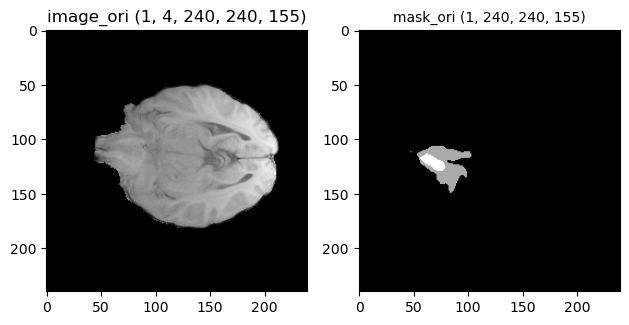

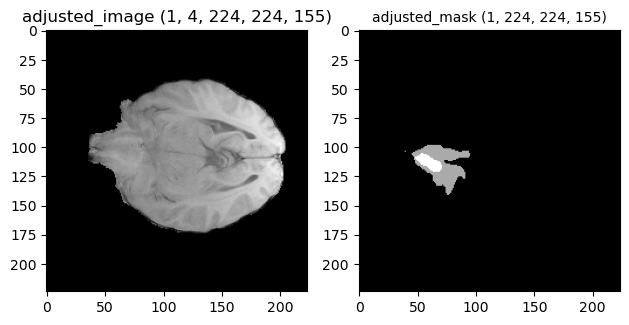

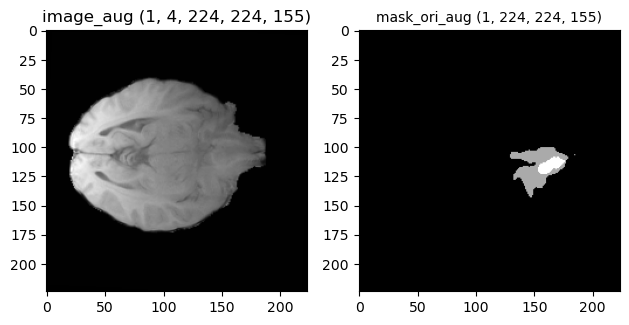

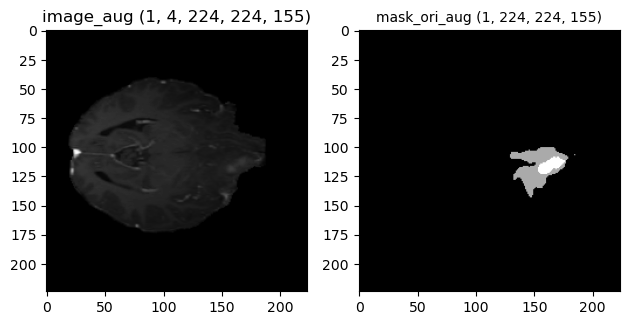

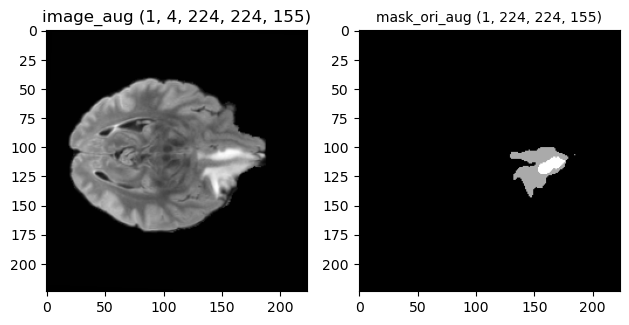

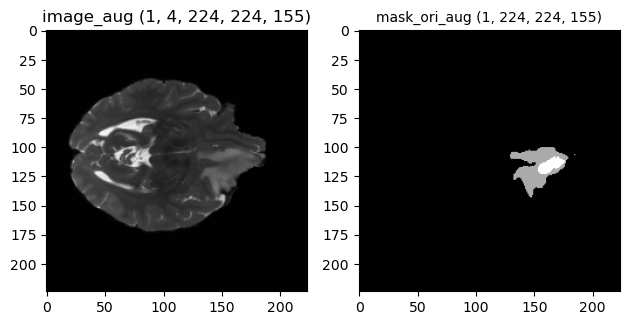

In [42]:
modelname = "gated3d"
imgsize = 224
imgdepth = 155
i=1
kfold=5
batch_size = 1 
path = r"E:\workplace\teases_implementation\dataset"

train_dataset = ImageToImage3D_SmallScale(Training = True ,shape = ( imgsize,imgsize , imgdepth), kfold = kfold, i =1, dataset_path=path )
dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


image_ori, mask_ori, adjusted_image, adjusted_mask, image_aug, mask_aug , my_name = next(iter(dataloader))


show_image_mask(image_ori ,mask_ori,'image_ori','mask_ori')
show_image_mask(adjusted_image ,adjusted_mask, 'adjusted_image','adjusted_mask')
show_image_mask(image_aug ,mask_aug,'image_aug','mask_ori_aug',0)
show_image_mask(image_aug ,mask_aug,'image_aug','mask_ori_aug',1)
show_image_mask(image_aug ,mask_aug,'image_aug','mask_ori_aug',2)
show_image_mask(image_aug ,mask_aug,'image_aug','mask_ori_aug',3)
#show_image_mask(my_image ,my_mask,'my_image','my_mask')


#for batch in dataloader:
    #print('**')
    #images, masks, filenames = batch
    #print("Batch Image Shape:", images.shape)
    #print("Batch Mask Shape:", masks.shape)
    #print("Filenames:", filenames)

In [39]:
#a , b , n = train_dataset